In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from datetime import datetime
import re

In [2]:
# Simplified implementation - import the enhanced classes from Hurricane V1
from Hurricane_V1 import Hurricane, HistoricalHurricane, SyntheticHurricane, HurricaneSimulation

# Or use the simple HurricaneSimulation class for basic functionality
class SimpleHurricaneAnalysis:
    def __init__(self, hurdat2_file, wind_farm_lat, wind_farm_lon):
        self.simulation = HurricaneSimulation(hurdat2_file, wind_farm_lat, wind_farm_lon)
    
    def analyze_hurricane(self, storm_id):
        """One-method hurricane analysis"""
        hurricane = (self.simulation.create_hurricane(storm_id)
                     .analyze_wind_farm_impact())
        hurricane.print_summary()
        hurricane.plot()
        return hurricane
    
    def quick_comparison(self, storm_ids, title="Hurricane Comparison"):
        """Quick comparison of multiple hurricanes"""
        hurricanes = []
        for storm_id in storm_ids:
            hurricane = (self.simulation.create_hurricane(storm_id)
                         .analyze_wind_farm_impact())
            hurricanes.append(hurricane)
        
        self.simulation.compare_hurricanes(hurricanes, title)
        return hurricanes

In [4]:
# Example usage with the clean implementation
hurdat2_file = 'project_folder/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt'
wind_farm_lat = 38.27
wind_farm_lon = -74.68

# Option 1: Use full HurricaneSimulation
simulation = HurricaneSimulation(hurdat2_file, wind_farm_lat, wind_farm_lon)

# Option 2: Use simplified analysis class
simple_analysis = SimpleHurricaneAnalysis(hurdat2_file, wind_farm_lat, wind_farm_lon)

Selected Hurricane: AL182012, SANDY

During Hurricane AL182012:
Distance from wind farm: 83.5 km
Maximum wind speed in hurricane: 75 knots
Estimated wind speed at wind farm: 86.8 knots
Wind direction at wind farm: 217.9 degrees


/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_5447/3871723749.py:238: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hurricane_data.loc[:, 'distance_km'] = distances
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_5447/3871723749.py:239: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hurricane_data.loc[:, 'wind_speed'] = wind_speeds
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_5447/3871723749.py:240: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

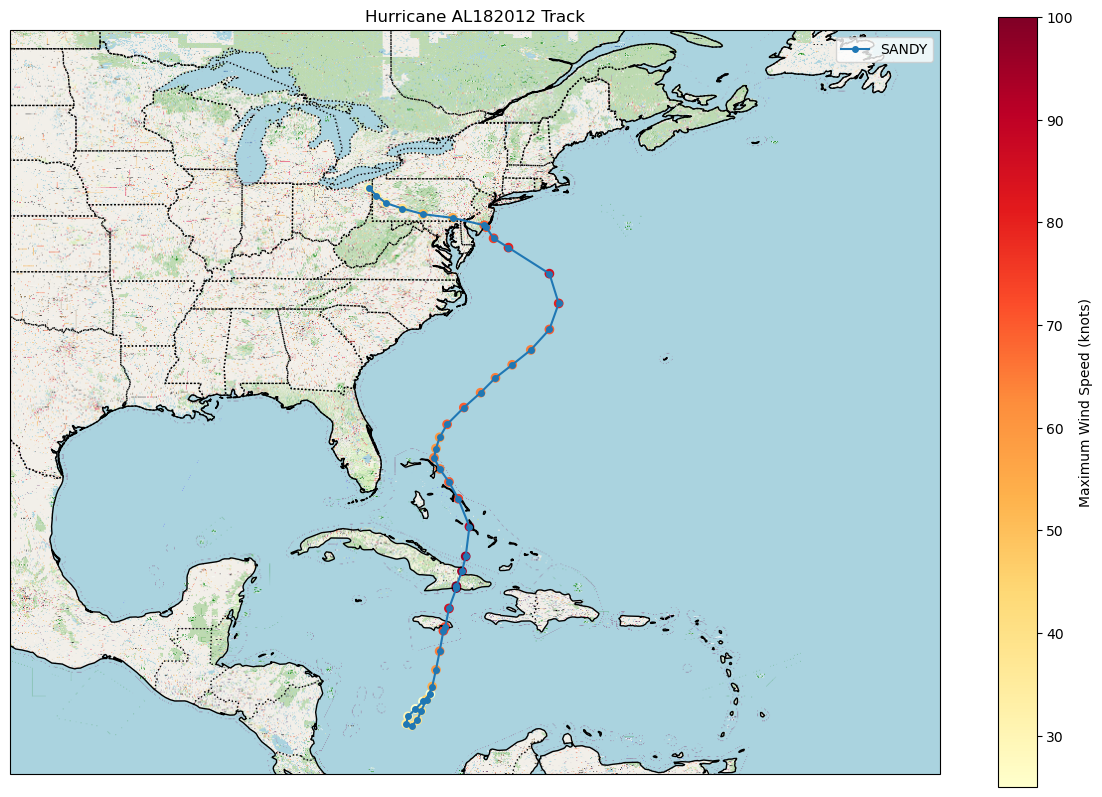

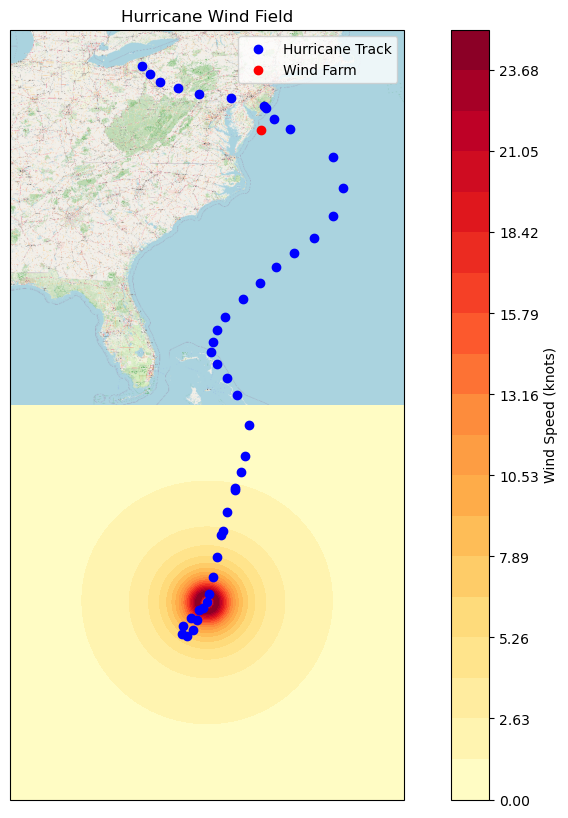

In [5]:
# Clean one-liner analysis
sandy = simple_analysis.analyze_hurricane('AL182012')

In [6]:
# Generate report with single method call
sandy.generate_report('sandy_wind_farm_analysis.csv')

Hurricane report generated and saved to hurricane_report.csv


In [ ]:
# Quick comparison of multiple storms
storm_ids = ['AL182012', 'AL092011', 'AL122005']  # Sandy, Irene, Katrina
hurricanes = simple_analysis.quick_comparison(storm_ids, "Major Atlantic Hurricanes")

In [ ]:
# Quick synthetic hurricane generation example
def generate_synthetic_example():
    """Simple example of synthetic hurricane generation"""
    
    # Train model on a few storms (this would take a few minutes)
    print("Training LSTM-VAE model (this may take a few minutes)...")
    training_storms = ['AL012012', 'AL022012', 'AL182012']  # Include Sandy
    train_losses, val_losses = simulation.train_lstm_vae(training_storms, epochs=30)
    
    # Generate synthetic version of Sandy
    sandy_historical = simulation.create_hurricane('AL182012').analyze_wind_farm_impact()
    synthetic_sandy = simulation.generate_synthetic_hurricane(sandy_historical)
    synthetic_sandy.analyze_wind_farm_impact()
    
    # Compare results
    print("\nComparison Results:")
    hist_summary = sandy_historical.get_wind_farm_summary()
    synth_summary = synthetic_sandy.get_wind_farm_summary()
    
    print(f"Historical Sandy - Closest: {hist_summary['closest_approach_km']:.1f} km, Max Wind: {hist_summary['max_wind_speed_knots']:.1f} knots")
    print(f"Synthetic Sandy - Closest: {synth_summary['closest_approach_km']:.1f} km, Max Wind: {synth_summary['max_wind_speed_knots']:.1f} knots")
    
    # Plot comparison
    simulation.compare_hurricanes([sandy_historical, synthetic_sandy], "Historical vs Synthetic Sandy")
    
    return sandy_historical, synthetic_sandy

# Uncomment the line below to run the example
# historical_sandy, synthetic_sandy = generate_synthetic_example()